# AV Incident EDA — Point-in-Time Report

**Snapshot date: 2026-06-02**  ·  Data window: SGO ADS incident reports through 2026-03-16

> **Point-in-time snapshot.** The SGO dataset refreshes periodically. Every
> number, chart, and ranking below reflects the data as of the snapshot date and
> may move on the next refresh. The
> structure, decisions, and caveats (the parts that survive a refresh)
> live in `eda/context/findings.md`; this report is the human-facing
> superset that also carries the findings, the central "what was and
> wasn't tried" coverage log, and next-step sparks.

This report curates existing EDA work — it does not run new
analyses. Light charts are recomputed live from the cleaned dataframe; heavier
visuals (LightGBM/SHAP, spaCy/displaCy, embeddings/UMAP) are linked out to
their owning notebooks rather than re-run here.

**Contents**
1. Data overview
2. Main steps taken
3. Interesting findings (curated, live light charts)
4. Coverage log — what was and wasn't tried (+ where AI helped vs. misled)
5. Backlog & deferred
6. Next-step sparks


## 0. Setup

Run in the `avird-2026-eda-target` Python 3.12 env (`source ~/claude_code_repos/my-uv-envs/avird-2026-eda-target/.venv/Scripts/activate`). Loads the two SGO CSVs, dedupes, treats, and attaches candidate targets — the same `eda_utils_*` pipeline the track notebooks use.

In [1]:
import sys, glob, warnings
warnings.filterwarnings('ignore')
sys.path.append('..')

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from eda_utils_sgo import (
    load_and_concat_csvs, vehicle_stopped_analysis, redacted_breakdown,
)
from eda_utils_dedupe import dedupe_same_incident
from eda_utils_treatment import apply_all_treatments
from eda_utils_targets import add_all_targets
import eda_utils_basic as eb
import eda_utils_co_impact as eci

pd.set_option('display.max_columns', 60)
plt.rcParams['figure.figsize'] = (9, 5)

In [2]:
# Load -> dedupe -> treat -> targets. The load step prints the old/new schema diff.
paths = sorted(glob.glob('../../data/nhtsa/SGO-2021-01_Incident_Reports_ADS*.csv'))
raw = load_and_concat_csvs(paths)
deduped = dedupe_same_incident(raw)
treated = apply_all_treatments(deduped)
df = add_all_targets(treated)

print(f'raw rows/cols      : {raw.shape}')
print(f'deduped rows/cols  : {deduped.shape}')
print(f'treated cols       : {treated.shape[1]}')
print(f'with targets cols  : {df.shape[1]}')

Only in SGO-2021-01_Incident_Reports_ADS_2025_06_16_to_2026_03_16.csv:
  Any Air Bags Deployed?
  Automation Feature Version
  Automation Feature Version CBI
  Engagement Status
  Make - Unknown
  Roadway-Degraded Surface
  Roadway-Missing/Degraded Marking
  Roadway-No Unusual Conditions
  Roadway-Other-See Narrative
  Roadway-Traffic Incident
  Roadway-Unknown
  Roadway-Wet Surface Condition
  Roadway-Work Zone
  Source - Internal Process Review
  Source - NHTSA VOQ
  Source - Other - See Narrative
  Source - Other Entity
  Source - State or Other Agency
  VIN Decoded
  Was Any Vehicle Towed?
  Weather - Dust Storm
  Weather - Fog/Smoke/Haze
  Weather - Partly Cloudy
  Weather - Severe Hurricane
  Weather - Structure-Indoor
  Weather - Unk - See Narrative
  Were All Passengers Belted?
Only in SGO-2021-01_Incident_Reports_ADS_to_2025_06_16.csv:
  ADAS/ADS Hardware Version
  ADAS/ADS Hardware Version - Unk
  ADAS/ADS Hardware Version CBI
  ADAS/ADS Software Version
  ADAS/ADS Software V

raw rows/cols      : (3120, 164)
deduped rows/cols  : (2344, 165)
treated cols       : 174
with targets cols  : 181


## 1. Data overview

**Sources.** Two NHTSA SGO ADS incident CSVs concatenated: an older file
(`…_to_2025_06_16`) and a newer one (`…_2025_06_16_to_2026_03_16`). They do **not
share the same schema** — a durable gotcha that shapes every downstream step
(see `eda/context/findings.md`). The loader prints which columns are old- or
new-only and any dtype mismatches.

**Dedupe.** The feed carries multiple reports per physical incident; we collapse
them to one canonical row (latest report wins, narratives concatenated). See
[`eda_utils_dedupe.py`](../eda_utils_dedupe.py) and
[`02_eda_utils_validate_2026.ipynb`](02_eda_utils_validate_2026.ipynb).


In [3]:
# Row counts and the duplicate-incident rate (point-in-time)
n_raw, n_dedup = len(raw), len(df)
print(f'raw reports                : {n_raw}')
print(f'canonical incidents (dedup): {n_dedup}')
print(f'collapsed as duplicates    : {n_raw - n_dedup} '
      f'({(n_raw - n_dedup) / n_raw:.1%} of raw reports)')

raw reports                : 3120
canonical incidents (dedup): 2344
collapsed as duplicates    : 776 (24.9% of raw reports)


In [4]:
# Schema split: how many columns are shared vs old/new-only
old_cols  = set(pd.read_csv(paths[1], nrows=0).columns)   # ..._to_2025_06_16
new_cols  = set(pd.read_csv(paths[0], nrows=0).columns)   # ..._2025_06_16_to_...
shared = old_cols & new_cols
print(f'shared columns   : {len(shared)}')
print(f'old-only columns : {len(old_cols - new_cols)}')
print(f'new-only columns : {len(new_cols - old_cols)}')
print('\nExamples old-only:', sorted(list(old_cols - new_cols))[:8])
print('Examples new-only:', sorted(list(new_cols - old_cols))[:8])

shared columns   : 89
old-only columns : 48
new-only columns : 27

Examples old-only: ['ADAS/ADS Hardware Version', 'ADAS/ADS Hardware Version - Unk', 'ADAS/ADS Hardware Version CBI', 'ADAS/ADS Software Version', 'ADAS/ADS Software Version - Unk', 'ADAS/ADS Software Version CBI', 'ADAS/ADS System Version', 'ADAS/ADS System Version - Unk']
Examples new-only: ['Any Air Bags Deployed?', 'Automation Feature Version', 'Automation Feature Version CBI', 'Engagement Status', 'Make - Unknown', 'Roadway-Degraded Surface', 'Roadway-Missing/Degraded Marking', 'Roadway-No Unusual Conditions']


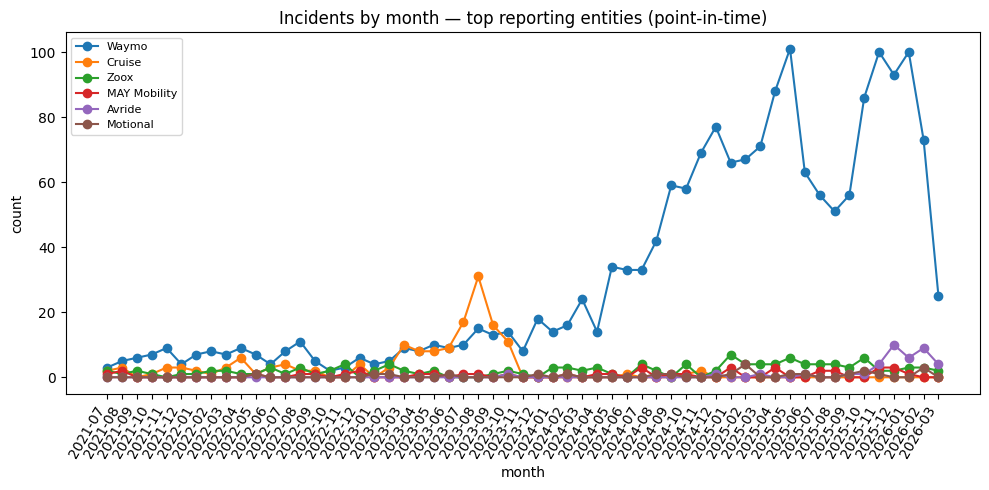

In [5]:
# Incidents by month, split by master_entity (top entities)
ax = eb.plot_monthly(df, 'Incident Date', group_col='master_entity', top_k_groups=6)
ax.set_title('Incidents by month — top reporting entities (point-in-time)')
plt.show()

## 2. Main steps taken

Each step is a short pointer to the owning notebook / util — the deep work lives
there, not inline.

| Step | What happened | Where |
|------|---------------|-------|
| **Initial explore** | Distributions, incidents by month/entity/time, contact-area matching + heatmap, word cloud, data-availability. | [`01_eda_initial_explore_2026.ipynb`](01_eda_initial_explore_2026.ipynb) |
| **Validate / consolidate** | Moving-vs-stopped × severity; entity consolidation sanity checks. | [`02_eda_utils_validate_2026.ipynb`](02_eda_utils_validate_2026.ipynb) |
| **Dedupe** | Collapse multiple reports per incident to one canonical row (latest wins; narratives concatenated). | [`eda_utils_dedupe.py`](../eda_utils_dedupe.py) |
| **Treatment** | Fuzzy categorical consolidation (Make/Model/Entity/Permit/State) + `master_entity` rollup, appended non-destructively. | [`eda_utils_treatment.py`](../eda_utils_treatment.py) |
| **Targets** | Build 7 candidate targets; keep `Injury Reported` and an SV-speed target (>=15 in notebook 07; `add_all_targets` defaults to >=10). | [`eda_utils_targets.py`](../eda_utils_targets.py), [`04_eda_target_exploration.ipynb`](04_eda_target_exploration.ipynb) |
| **Topics / NLP** | LDA + NMF (sklearn + gensim) over narratives. | [`03_eda_basic_topics_2026.ipynb`](03_eda_basic_topics_2026.ipynb), [`eda_utils_topics.py`](../eda_utils_topics.py) |
| **spaCy** | Linguistic features, NER, Matcher/PhraseMatcher, displaCy, similarity (3.12 sidecar). | [`05_eda_spacy_2026.ipynb`](05_eda_spacy_2026.ipynb), [`eda_utils_spacy.py`](../eda_utils_spacy.py) |
| **Embeddings** | `bge-base-en-v1.5` via HF, cached; KeyBERT / BERTopic / neighbors / UMAP. | [`04_eda_narrative_embeddings_2026.ipynb`](04_eda_narrative_embeddings_2026.ipynb), [`embeddings_notes.md`](embeddings_notes.md) |
| **Injury target analysis** | Univariate ranking + LightGBM/LR/GBM + SHAP + interaction heatmaps. | [`07_eda_target_injury_2026.ipynb`](07_eda_target_injury_2026.ipynb), [review](../../docs/reviews/2026-05-25-code-review-injury-target.md) |


## 3. Interesting findings

Curated from the harvest. Light charts are recomputed live below; heavy visuals
are linked to their notebooks.

### 3.1 Most incidents are low-speed — often a stopped/slow SV
About half of incidents have the subject vehicle essentially **stopped**, and
most "moving" incidents are at low speed. A recurring read of the narratives /
target work: a faster crash partner striking a slow or stopped AV, rather than a
fast-moving AV. (SV precrash speed is dominated by zero/low values, so analyze it
in buckets — see findings caveat.)


,count,share
sv_motion,,
stopped,1309,0.558
moving,1019,0.435
unknown,16,0.007


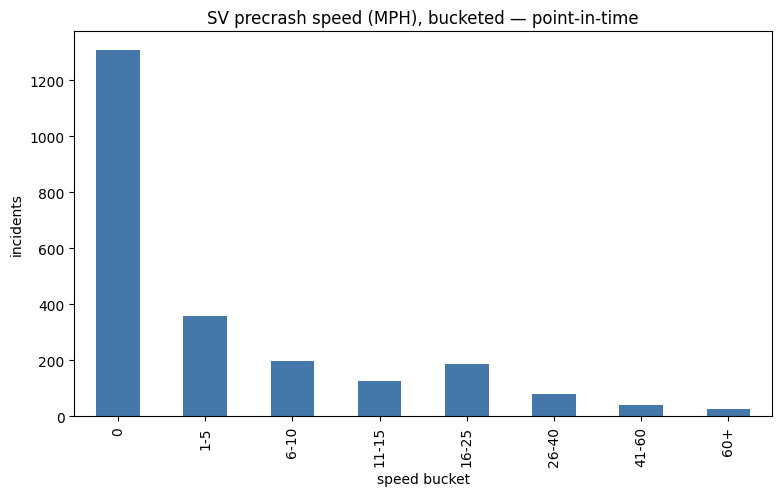

In [6]:
overall, by_severity = vehicle_stopped_analysis(df)
display(overall)

# SV precrash speed distribution (bucketed) — the raw column is heavily zero-piled
speed = pd.to_numeric(df['SV Precrash Speed (MPH)'], errors='coerce')
bins = [-0.1, 0.9, 5, 10, 15, 25, 40, 60, 200]
labels = ['0', '1-5', '6-10', '11-15', '16-25', '26-40', '41-60', '60+']
buckets = pd.cut(speed, bins=bins, labels=labels)
ax = buckets.value_counts().reindex(labels).plot(kind='bar', color='#4477aa')
ax.set_title('SV precrash speed (MPH), bucketed — point-in-time')
ax.set_xlabel('speed bucket'); ax.set_ylabel('incidents')
plt.show()

### 3.2 Injury is rare and imbalanced; entity rates vary
`Injury Reported` derives from `Highest Injury Severity Alleged` and is strongly
imbalanced. Per-entity injury rates differ — but small samples make the tails
noisy, so we gate on a minimum incident count. Evaluate any model with AUC /
PR-AUC on a stratified holdout, not accuracy.


Injury Reported positives: 222 / 2344  (9.5%) — point-in-time


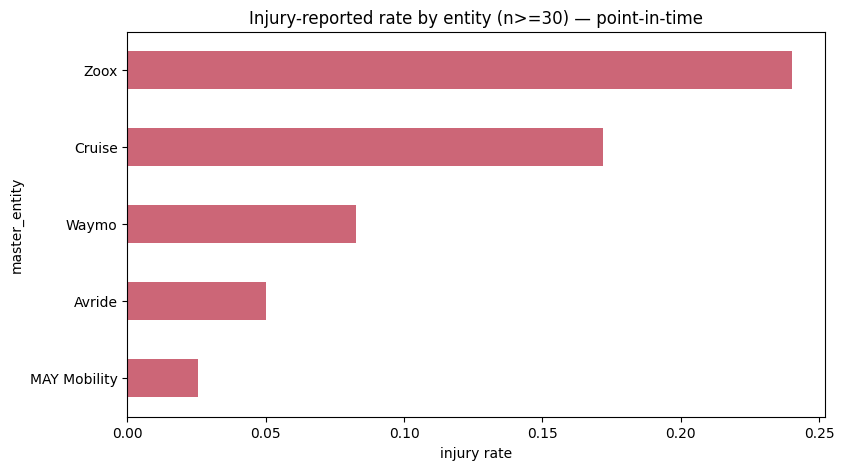

,rate,n
master_entity,,
Zoox,0.240,125
Cruise,0.172,157
Waymo,0.083,1803
Avride,0.050,40
MAY Mobility,0.026,39


In [7]:
pos = int(df['Injury Reported'].sum()); n = len(df)
print(f'Injury Reported positives: {pos} / {n}  ({pos / n:.1%}) — point-in-time')

rate = (df.groupby('master_entity')['Injury Reported']
          .agg(rate='mean', n='count')
          .query('n >= 30')
          .sort_values('rate', ascending=False))
ax = rate['rate'].plot(kind='barh', color='#cc6677')
ax.set_title('Injury-reported rate by entity (n>=30) — point-in-time')
ax.set_xlabel('injury rate'); plt.gca().invert_yaxis()
plt.show()
display(rate.round(3))

### 3.3 Contact areas: who hits whom, and where
Per-incident SV×CP contact-area pairings (the corrected matching — the first
independent-count version was wrong; see coverage log). A website candidate:
collapse to front/rear/side, then drill into granular areas.


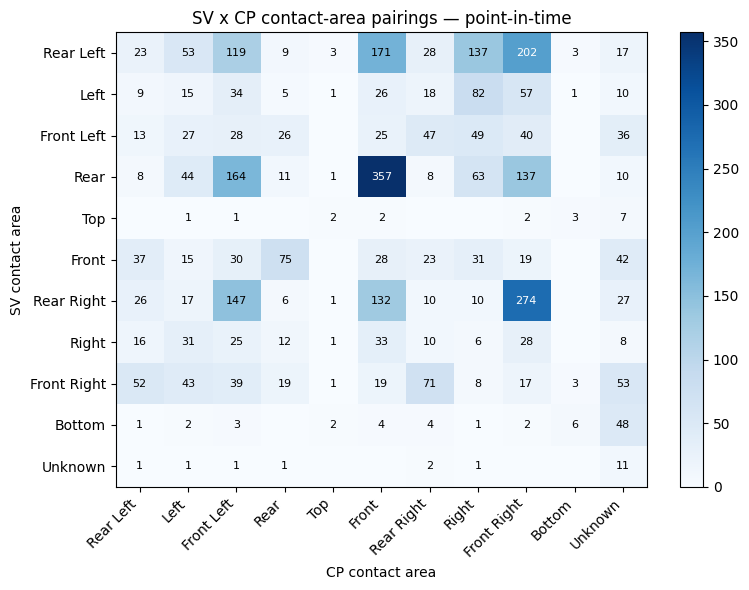

In [8]:
ax = eci.plot_contact_area_pair_heatmap(df)
ax.set_title('SV x CP contact-area pairings — point-in-time')
plt.show()

### 3.4 Pre-crash movement pairings
SV vs CP pre-crash movement. The SV is frequently making a turn or proceeding
straight while the CP is doing something else — a candidate website heatmap and a
source of ideas for a "dangerous maneuver" target (backlogged).


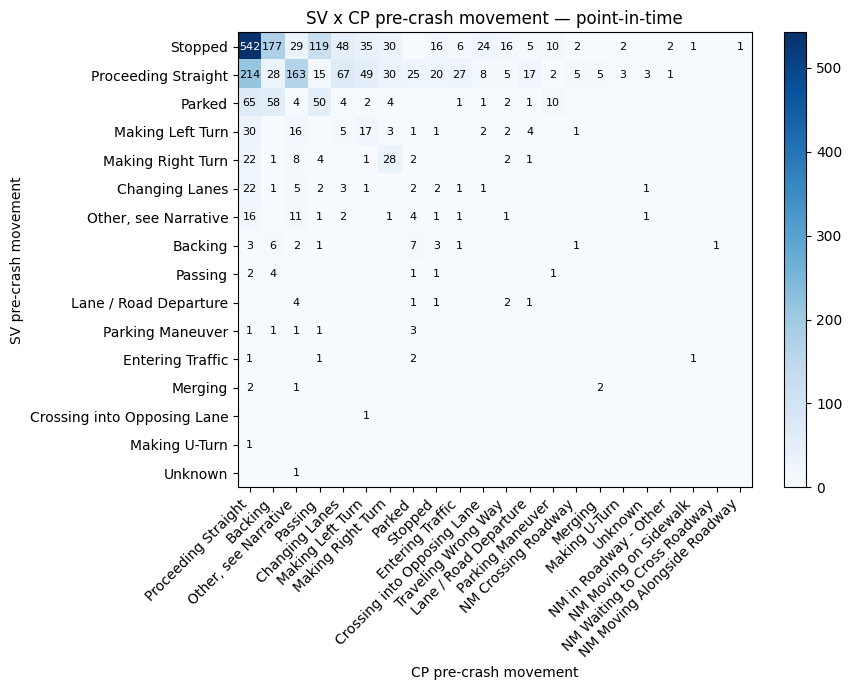

In [9]:
ax = eci.plot_pre_crash_movement_heatmap(df)
ax.set_title('SV x CP pre-crash movement — point-in-time')
plt.show()

### 3.5 Narrative redaction is concentrated in a few entities
Redaction is **not** uniform. Several now-defunct entities (Cruise, Argo AI,
Motional) redact at or near 100% of their narratives; **Tesla** is the notable
redactor among currently-active entities; high-volume Waymo redacts only a small
fraction. Markers: `[REDACTED, MAY CONTAIN CONFIDENTIAL BUSINESS INFORMATION]`,
`XXX`, `CBI`.


In [10]:
red = redacted_breakdown(df, ['Narrative'], group_col='master_entity', top_k=12)
display(red)

,master_entity,column,redacted,total,share
0,Cruise,Narrative,157,157,1.000
1,Waymo,Narrative,83,1803,0.046
2,Argo AI,Narrative,18,20,0.900
3,Tesla,Narrative,15,15,1.000
4,Motional,Narrative,14,22,0.636
5,Admt Vwgoa,Narrative,5,8,0.625
6,Torc Robotics,Narrative,3,3,1.000
7,Zoox,Narrative,2,125,0.016
8,Kodiak Robotics,Narrative,2,6,0.333
9,Colorado School of Mines,Narrative,2,2,1.000


### 3.6 Topics, spaCy, embeddings — linked out (heavy)
Not re-run here (heavy pipelines, and the embeddings cache / spaCy artifacts are
gitignored and not regenerated at export time). See:

- **Topics (LDA/NMF):** [`03_eda_basic_topics_2026.ipynb`](03_eda_basic_topics_2026.ipynb).
  NMF with more n-grams hinted at distinct Waymo phases (early parking-lot/Arizona
  vs. later passenger-car); GM/Cruise and Zoox looked isolated.
- **spaCy:** [`05_eda_spacy_2026.ipynb`](05_eda_spacy_2026.ipynb) — the
  Matcher/PhraseMatcher maneuver table is a fun website candidate
  (`build_maneuver_matcher`).
- **Embeddings:** [`04_eda_narrative_embeddings_2026.ipynb`](04_eda_narrative_embeddings_2026.ipynb)
  + [`embeddings_notes.md`](embeddings_notes.md). ⚠️ The notes' "what worked /
  surprised / useful" sections are **unfilled TODOs** — a known gap.
- **Injury SHAP / interactions:** [`07_eda_target_injury_2026.ipynb`](07_eda_target_injury_2026.ipynb).
  Sensible drivers (passengers-belted, pre-crash movement, crash-with), but
  co-observed crash-outcome columns dominate unless excluded — and the committed
  ranking predates a leakage fix (see coverage log / review).


## 4. Coverage log — what was and wasn't tried

The single consolidated account. Raw backlog lives in
[`eda_to_do.md`](eda_to_do.md); this consolidates the DONE/backlog lines from `eda_to_do.md` and the per-track plans under `docs/plans/`.

### Tried (done)
| Area | Tried | Outcome / note |
|------|-------|----------------|
| Structure | Two-CSV concat, schema-diff surfacing | Old/new schema split is the central data caveat |
| Dedup | Same-incident consolidation (latest wins, narrative concat) | ~⅓ of raw reports collapse; separator pollutes NLP segmentation |
| Treatment | Fuzzy consolidation + `master_entity` rollup | Worked well; emits reviewable mapping |
| Explore | Month/entity/time tables, contact-area heatmap, word cloud, data-availability | Time-of-day uninterpretable w/o exposure |
| Targets | 7 candidates built; kept `Injury Reported` + an SV-speed target (>=15 in nb 07; default >=10) | Injury imbalanced (~10%, see §3.2) |
| Univariate | AUC/KS/MI/chi²/correlation ranking | Cross-dtype MI sort is a known weakness |
| Models | LightGBM RF/GBM + LR, SHAP, interaction heatmaps, stub tree | Co-observed outcomes dominate; needs pre-incident-only pass |
| Topics | LDA + NMF (sklearn + gensim) | Hints of Waymo phases; BERTopic underwhelmed |
| spaCy | Full capability tour incl. Matcher/PhraseMatcher | Maneuver matcher promising |
| Embeddings | bge-base via HF, cached; KeyBERT/BERTopic/neighbors/UMAP | Wiring solid; qualitative writeup never finished |

### Not tried / left open (deliberate)
- Pre-incident-only contrast model (excluding co-observed outcome columns) — designed, not run to conclusion.
- Multi-class severity target; "dangerous maneuver" target from pre-crash movement.
- Topic-model rigor (K sweeps, coherence plots, more seeds); second embedding model; outlier/novelty detection on embeddings.
- Narrative ontology (text → NER → agent graph → golden eval) — see [`narrative_ontology.md`](../../private/scratch_plans/narrative_ontology.md).
- Exposure-aware analysis (per-mile rates) — mileage/exposure not in data.
- Location analysis — lat/long/address not present in the feed.

### Where AI helped vs. misled (origin R17)
**Helped**
- Scaffolding the reusable `eda_utils_*` layer with consistent function contracts.
- Multi-reviewer passes caught two *subtle, real* bugs the author missed: a
  cross-target **leakage** (`SV Speed >= 15` leaked into the `Injury Reported`
  feature ranking — [review](../../docs/reviews/2026-05-25-code-review-injury-target.md))
  and a dead retry path (`_is_transient` missed `InferenceTimeoutError`, so
  embedding-API timeouts silently escaped all retries —
  [review](../../docs/code-reviews/2026-05-17-001-embeddings-track-review.md)).

**Misled / friction**
- Got HF / KeyBERT / BERTopic *precomputed-embedding* API seams wrong more than once.
- First instinct often a heavier abstraction than this EDA needed.
- Hand-maintained drop-lists drifted from their source of truth — the direct
  cause of the leakage above. Lesson now in `findings.md`: derive drop-sets from
  the target-name source, never a static list.
- The first contact-area matching code was simply wrong ("seems odd… not
  matching… yeah this is wrong") and needed human validation before the heatmap
  could be trusted.


## 5. Backlog & deferred — **not done this phase**

Clearly marked not-done. Full raw list: [`eda_to_do.md`](eda_to_do.md).

- **`06_eda_clean_up_summary.ipynb` is unfinished** — a data-cleanup/orchestration
  notebook with open TODOs, *not* a findings summary. Its plumbing is deferred.
- **NLP follow-ups:** narrative ontology, narrative classification, BERTopic
  alternatives, embedding-model comparison, narrative-dedupe via matching.
- **Better targets:** seriousness via data + LLM, weird-maneuver target, incident
  tracking for conclusions.
- **Website surfaces (separate phase):** contact-area heatmap with filters,
  pre-crash-movement heatmap, redaction %-by-entity, cleaned-data browser,
  target-vs-key-columns, time/region/company breakdowns, displaCy / maneuver-matcher demos.
- **Infra / skill:** incremental-analysis skill on new data releases, MCP-queryable
  findings, test cases for the EDA utils, another agent code-review pass.
- **Data gaps:** data dictionary doesn't note schema versions; lat/long/address
  absent; mileage/exposure missing; FOIA / data-availability for police reports.

> Publishing this report (or interactive successors) to the deployed site is the
> **website build phase**, not this closeout.


## 6. Next-step sparks

- Run the **pre-incident-only** injury model and present it side-by-side with the
  all-features SHAP ranking — separates "what predicts injury" from "what is
  co-recorded with injury."
- Promote the **contact-area** and **pre-crash-movement** heatmaps into the first
  interactive website surfaces (front/rear/side toggle, entity filter).
- Finish the **embeddings writeup** (fill the `embeddings_notes.md` TODOs) while
  the cache can still be cheaply rebuilt, then try a second embedding model.
- Stand up an **incremental-analysis skill**: on each SGO refresh, report what's
  new and what changed against this snapshot.
- Bucket **SV precrash speed** properly and revisit the low/no-speed cohort: of
  those, how many were the AV legitimately stopped vs. plausibly at fault.
- See many other backlog/todos/items


## 7. Use of AI
- Heavily uses Claude Code and Opus 4.7, which was one of the goals of this EDA phase. How can coding AI assist with EDA? What parts can it handle well or not?
- I found Claude good at writing functions to .py files. The work on the .ipynb files, summarizing findings, and interating on results could be a bit hit or miss. Claude would frequently ask for permission to read, run, or edits cells. Asking Claude to write from a .py file to static artifacts produced a mess of hundreds of artifacts. Finding the right balance and learning where to lean on the AI more will be helpful.
- I still had to review many of the functions because some initial versions may have been technically correct but missed the goal. In particular for the crash area and pre-movement heatmap matches I had to hold Claude's hand through iterations to make sure the point was understood and the function was fixed correctly.
- Claude was great at iterating on the NLP work, explaining the parts, and helping tune parameters. Some stuff fell out nearly correctly, like the fuzzy logic and some of the basic NLP stuff. Some of the more advanced stuff would be helpful if Claude could iterate and try different ideas though I likely needed to give it a better harness.
- I strugged to turn the result and findings into an agent accessible and usable context directory. This is in the backlog of things to improve and devote more time too.

---
*Generated 2026-06-02. Point-in-time snapshot — numbers reflect data through
2026-03-16 and will change on refresh. Durable findings: `eda/context/findings.md`.*